# LOAD DATA 

In [2]:
import pandas as pd

df = pd.read_csv("Dataset/placedata v2.0 synthetic.csv")

In [3]:
print(df.head())

   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating ExtracurricularActivities  \
0                 65               4.4                        No   
1                 90               4.0                       Yes   
2                 82               4.8                       Yes   
3                 85               4.4                       Yes   
4                 86               4.5                       Yes   

  PlacementTraining  SSC_Marks  HSC_Marks PlacementStatus  
0                No         61         79       NotPlaced  
1               Yes         78         82   

# DATA CLEANING

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  str    
 8   PlacementTraining          10000 non-null  str    
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  str    
dtypes: float64(2), int64(7), str(3)
memory usage: 937.6 KB
None


In [5]:
print(df.isnull().sum())

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64


In [6]:
df.drop("StudentID", axis=1, inplace=True)

In [7]:
df.isnull().sum()

CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

In [8]:
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].map({'Yes':1, 'No':0})
df['PlacementTraining'] = df['PlacementTraining'].map({'Yes':1, 'No':0})

In [9]:
df['PlacementStatus'] = df['PlacementStatus'].map({'Placed':1, 'NotPlaced':0})

In [10]:
print(df.dtypes)

CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities      int64
PlacementTraining              int64
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus                int64
dtype: object


In [11]:
df.drop_duplicates(inplace=True)

# EDA 

<Axes: >

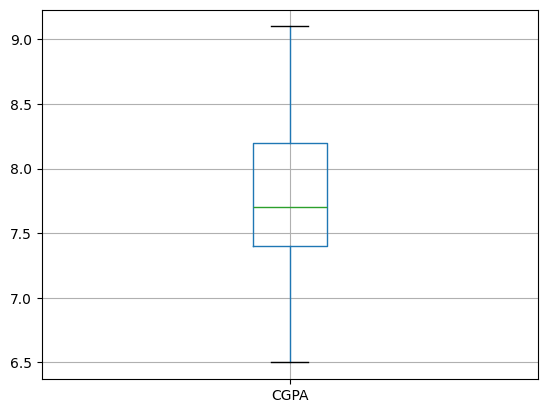

In [12]:
df.boxplot(column='CGPA')

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('PlacementStatus', axis=1))

In [14]:
print(df.head())

   CGPA  Internships  Projects  Workshops/Certifications  AptitudeTestScore  \
0   7.5            1         1                         1                 65   
1   8.9            0         3                         2                 90   
2   7.3            1         2                         2                 82   
3   7.5            1         1                         2                 85   
4   8.3            1         2                         2                 86   

   SoftSkillsRating  ExtracurricularActivities  PlacementTraining  SSC_Marks  \
0               4.4                          0                  0         61   
1               4.0                          1                  1         78   
2               4.8                          1                  0         79   
3               4.4                          1                  1         81   
4               4.5                          1                  1         74   

   HSC_Marks  PlacementStatus  
0         79

In [15]:
print(df.describe())

              CGPA  Internships     Projects  Workshops/Certifications  \
count  9928.000000  9928.000000  9928.000000               9928.000000   
mean      7.693946     1.042808     2.019944                  1.006849   
std       0.639961     0.663699     0.867118                  0.903612   
min       6.500000     0.000000     0.000000                  0.000000   
25%       7.400000     1.000000     1.000000                  0.000000   
50%       7.700000     1.000000     2.000000                  1.000000   
75%       8.200000     1.000000     3.000000                  2.000000   
max       9.100000     2.000000     3.000000                  3.000000   

       AptitudeTestScore  SoftSkillsRating  ExtracurricularActivities  \
count        9928.000000       9928.000000                9928.000000   
mean           79.376209          4.320679                   0.582595   
std             8.140884          0.411211                   0.493156   
min            60.000000          3.00000

EDA

In [16]:
print(df.shape)

(9928, 11)


In [17]:
print(df.columns)

Index(['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
       'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities',
       'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus'],
      dtype='str')


In [18]:
print(df.describe())

              CGPA  Internships     Projects  Workshops/Certifications  \
count  9928.000000  9928.000000  9928.000000               9928.000000   
mean      7.693946     1.042808     2.019944                  1.006849   
std       0.639961     0.663699     0.867118                  0.903612   
min       6.500000     0.000000     0.000000                  0.000000   
25%       7.400000     1.000000     1.000000                  0.000000   
50%       7.700000     1.000000     2.000000                  1.000000   
75%       8.200000     1.000000     3.000000                  2.000000   
max       9.100000     2.000000     3.000000                  3.000000   

       AptitudeTestScore  SoftSkillsRating  ExtracurricularActivities  \
count        9928.000000       9928.000000                9928.000000   
mean           79.376209          4.320679                   0.582595   
std             8.140884          0.411211                   0.493156   
min            60.000000          3.00000

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 

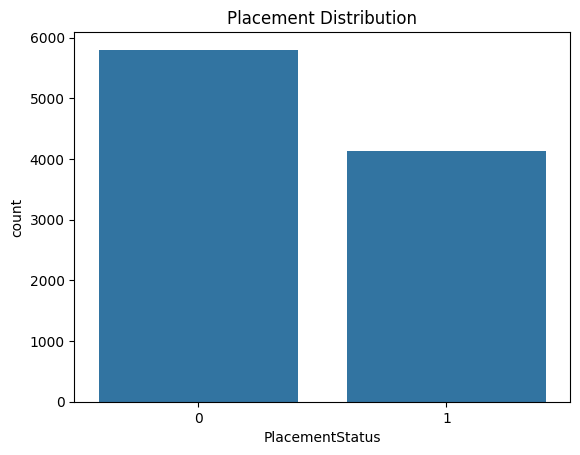

In [20]:
plt.figure()
sns.countplot(x='PlacementStatus', data=df)
plt.title("Placement Distribution")
plt.show()

“Dataset me placed aur not placed students ka distribution dikh raha hai. Agar placed zyada hain to placement rate high hai.”

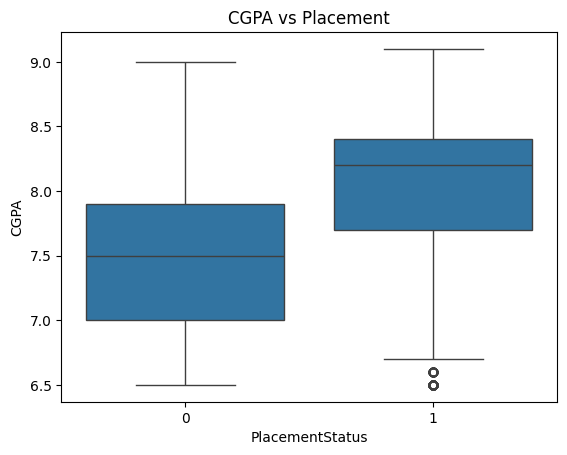

In [21]:
plt.figure()
sns.boxplot(x='PlacementStatus', y='CGPA', data=df)
plt.title("CGPA vs Placement")
plt.show()

“Placed students ka CGPA generally higher hai, jo batata hai ki academic performance important factor hai.”

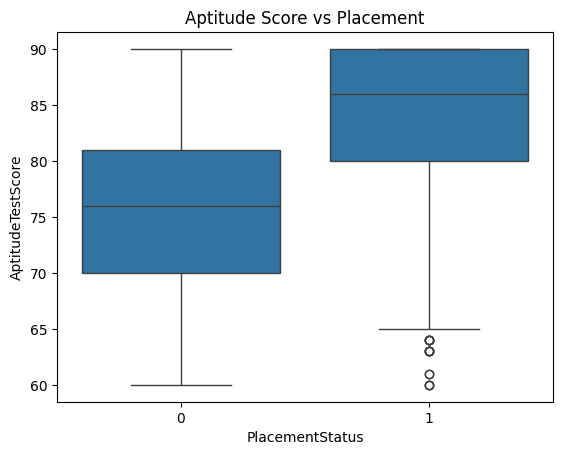

In [22]:
plt.figure()
sns.boxplot(x='PlacementStatus', y='AptitudeTestScore', data=df)
plt.title("Aptitude Score vs Placement")
plt.show()

“Higher aptitude score wale students ke placement chances zyada hain.”

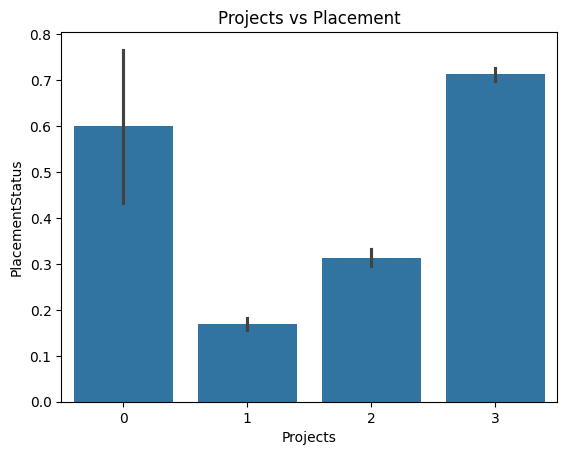

In [23]:
plt.figure()
sns.barplot(x='Projects', y='PlacementStatus', data=df)
plt.title("Projects vs Placement")
plt.show()

“Jitne zyada projects, utni placement probability high.”

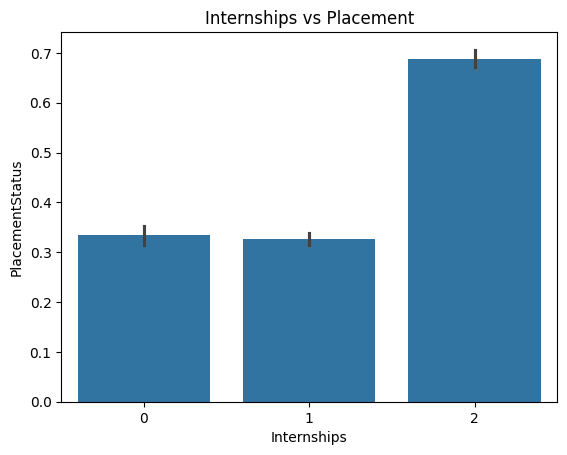

In [24]:
plt.figure()
sns.barplot(x='Internships', y='PlacementStatus', data=df)
plt.title("Internships vs Placement")
plt.show()

“Internship experience placement me strong positive impact deta hai.”

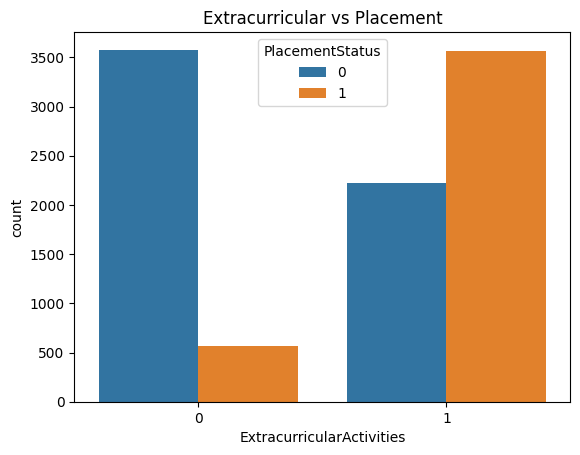

In [25]:
plt.figure()
sns.countplot(x='ExtracurricularActivities', hue='PlacementStatus', data=df)
plt.title("Extracurricular vs Placement")
plt.show()

“Extracurricular activities wale students ka placement slightly better hai.”

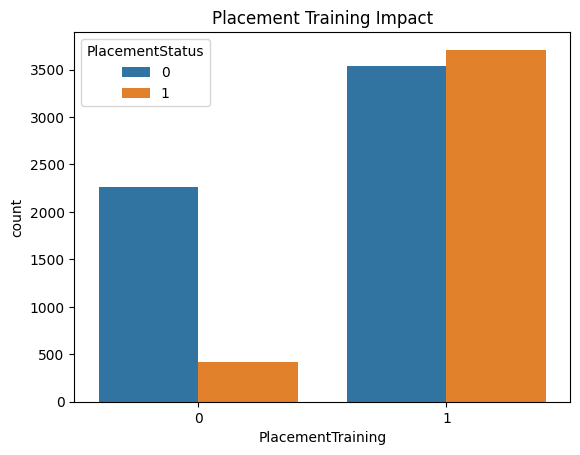

In [26]:
plt.figure()
sns.countplot(x='PlacementTraining', hue='PlacementStatus', data=df)
plt.title("Placement Training Impact")
plt.show()

“Placement training lene wale students ke placement chances significantly high hain.”

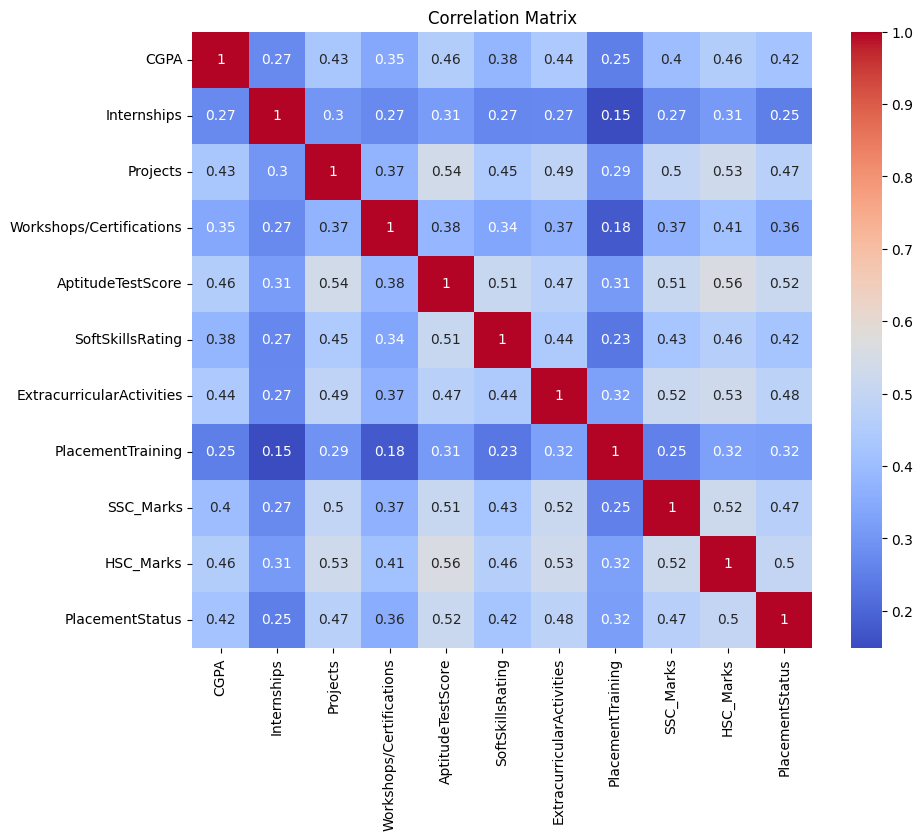

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

“CGPA, Aptitude Score, aur Internships ka placement ke saath positive correlation hai.”

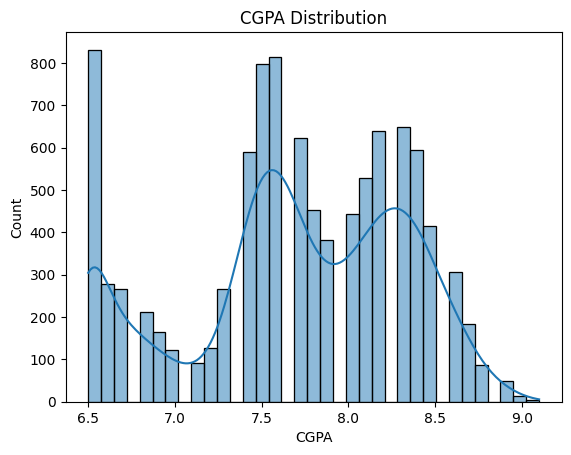

In [28]:
plt.figure()
sns.histplot(df['CGPA'], kde=True)
plt.title("CGPA Distribution")
plt.show()

“Most students ka CGPA 6–8 range me hai.”

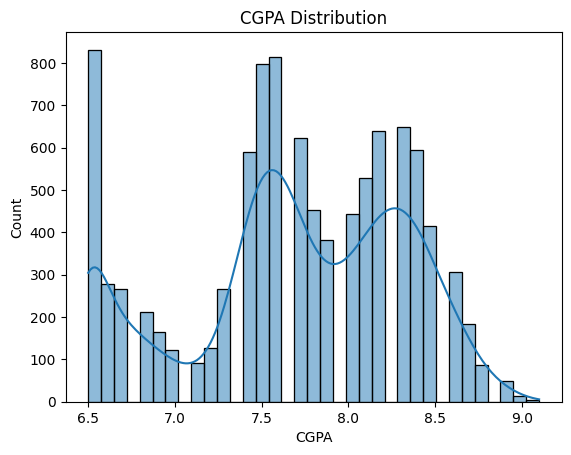

In [29]:
plt.figure()
sns.histplot(df['CGPA'], kde=True)
plt.title("CGPA Distribution")
plt.show()

Students with higher CGPA have better placement chances.

# Machine Learning model start 

In [30]:
X = df.drop('PlacementStatus', axis=1)  # Input
y = df['PlacementStatus']               # Output

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8031218529707955


In [36]:
model.predict_proba(X_test)

array([[0.13350948, 0.86649052],
       [0.93879591, 0.06120409],
       [0.57034189, 0.42965811],
       ...,
       [0.95838473, 0.04161527],
       [0.35567478, 0.64432522],
       [0.81063844, 0.18936156]], shape=(1986, 2))

In [37]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[964 224]
 [167 631]]


In [38]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
# from sklearn.ensemble import RandomForestClassifier

# rf = RandomForestClassifier()
# rf.fit(X_train, y_train)

# y_pred_rf = rf.predict(X_test)

# print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.7900302114803626


# Skill Gap Analyzer Logic

In [ ]:
# def skill_gap(input_data):
#     suggestions = []
    
#     if input_data['CGPA'] < 7:
#         suggestions.append("Improve your CGPA (Target: 7+)")

#     if input_data['Internships'] == 0:
#         suggestions.append("Do at least 1 internship")

#     if input_data['Projects'] < 2:
#         suggestions.append("Build more projects (Minimum 2)")

#     if input_data['AptitudeTestScore'] < 70:
#         suggestions.append("Improve aptitude skills")

#     if input_data['SoftSkillsRating'] < 3:
#         suggestions.append("Improve communication skills")

#     if input_data['PlacementTraining'] == 0:
#         suggestions.append("Join placement training program")

#     return suggestions

In [ ]:
# sample_student = {
#     'CGPA': 6.5,
#     'Internships': 0,
#     'Projects': 1,
#     'AptitudeTestScore': 60,
#     'SoftSkillsRating': 2,
#     'PlacementTraining': 0
# }

# print(skill_gap(sample_student))

['Improve your CGPA (Target: 7+)', 'Do at least 1 internship', 'Build more projects (Minimum 2)', 'Improve aptitude skills', 'Improve communication skills', 'Join placement training program']


In [ ]:
# def skill_gap(input_data):
#     suggestions = []
    
#     if input_data['CGPA'] < 7:
#         suggestions.append("📚 Improve CGPA by focusing on core subjects")

#     if input_data['Internships'] == 0:
#         suggestions.append("💼 Apply for internships on Internshala/LinkedIn")

#     if input_data['Projects'] < 2:
#         suggestions.append("🛠️ Build 2-3 real-world projects")

#     if input_data['AptitudeTestScore'] < 70:
#         suggestions.append("🧠 Practice aptitude daily (Quant + Reasoning)")

#     if input_data['SoftSkillsRating'] < 3:
#         suggestions.append("🗣️ Improve communication via mock interviews")

#     if input_data['PlacementTraining'] == 0:
#         suggestions.append("🎯 Join placement training or mock tests")

#     return suggestions

In [ ]:
# def analyze_student(input_data, probability):
    
#     suggestions = skill_gap(input_data)
    
#     if probability < 0.5:
#         level = "High Risk ❌"
#     elif probability < 0.75:
#         level = "Moderate ⚠️"
#     else:
#         level = "Good Chance ✅"
    
#     return level, suggestions